In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [230]:
df = pd.read_csv('Test_data.csv')
df

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,0,70


In [231]:
df.shape

(23490, 13)

In [232]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


#### Handle Null Values
##### 1) Detect Null values¶
##### 2) Returns column wise sum of null values

In [233]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64

#### 3) Drop all the rows contains null values

In [234]:
df.dropna(inplace=True)

In [235]:
df.shape

(20819, 13)

In [236]:
#To Check Null Value is Remove/ Drop 
df.isnull().sum()

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
dtype: int64

#### Detect Duplicates Value

In [237]:
df.duplicated().sum()

np.int64(0)

#### Check Data Types

In [238]:
df.dtypes

employee_id               int64
department               object
region                   object
education                object
gender                   object
recruitment_channel      object
no_of_trainings           int64
age                       int64
previous_year_rating    float64
length_of_service         int64
KPIs_met >80%             int64
awards_won?               int64
avg_training_score        int64
dtype: object

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20819 entries, 1 to 23489
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           20819 non-null  int64  
 1   department            20819 non-null  object 
 2   region                20819 non-null  object 
 3   education             20819 non-null  object 
 4   gender                20819 non-null  object 
 5   recruitment_channel   20819 non-null  object 
 6   no_of_trainings       20819 non-null  int64  
 7   age                   20819 non-null  int64  
 8   previous_year_rating  20819 non-null  float64
 9   length_of_service     20819 non-null  int64  
 10  KPIs_met >80%         20819 non-null  int64  
 11  awards_won?           20819 non-null  int64  
 12  avg_training_score    20819 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 2.2+ MB


In [240]:
df.columns  # Check Columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'KPIs_met >80%', 'awards_won?',
       'avg_training_score'],
      dtype='object')

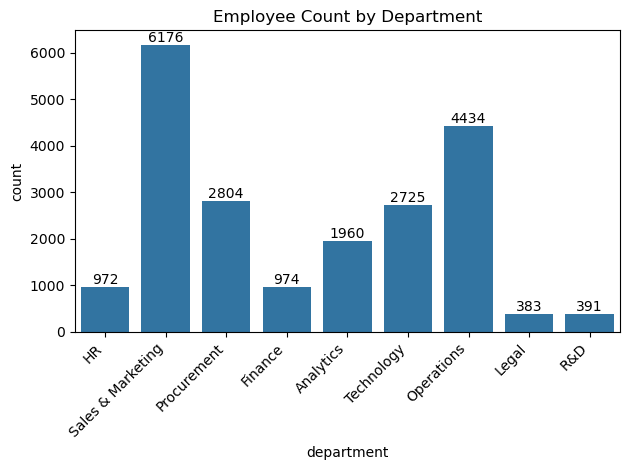

In [241]:
ax = sns.countplot(data = df, x = 'department')
ax.bar_label(ax.containers[0]) #To Display numbers:bar_label: Function to displayed the label(as the number), 0th index for 1 Category
plt.title('Employee Count by Department')
plt.xticks(rotation=45,ha='right')# rotate the X-axis labels by 45 degrees
plt.tight_layout()
plt.show()

#### Compare Two Features

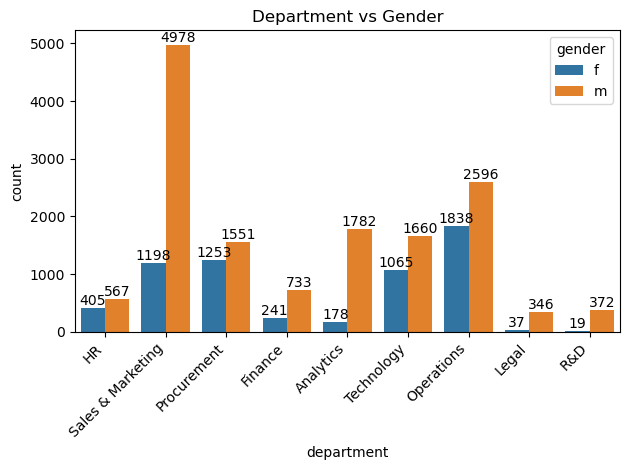

In [242]:
ax = sns.countplot(data = df, x = 'department', hue = 'gender')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Department vs Gender')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()


#### Plot All Categorical Columns

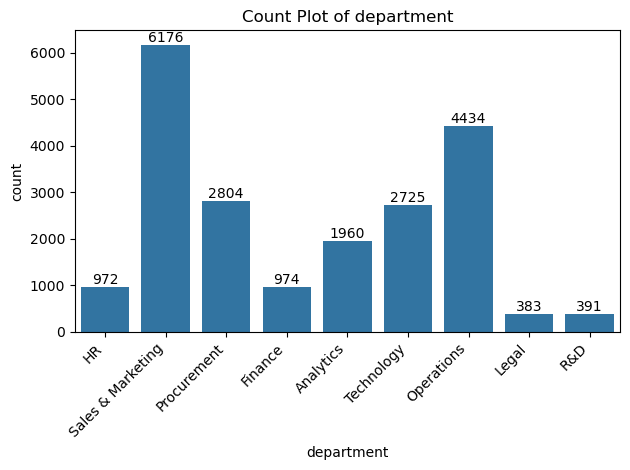

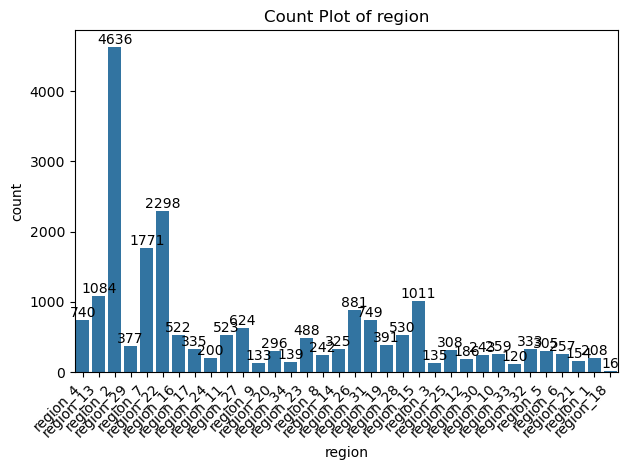

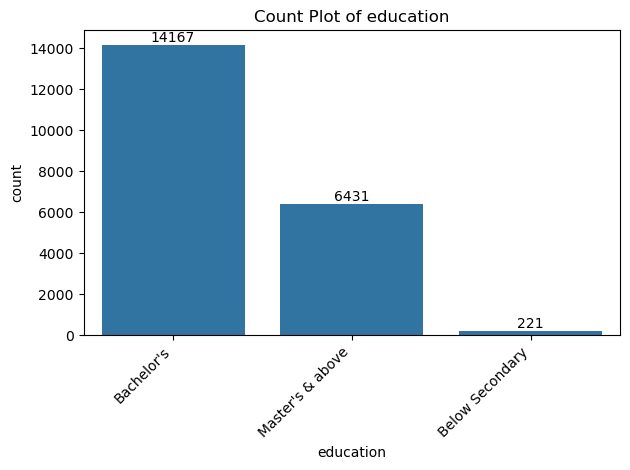

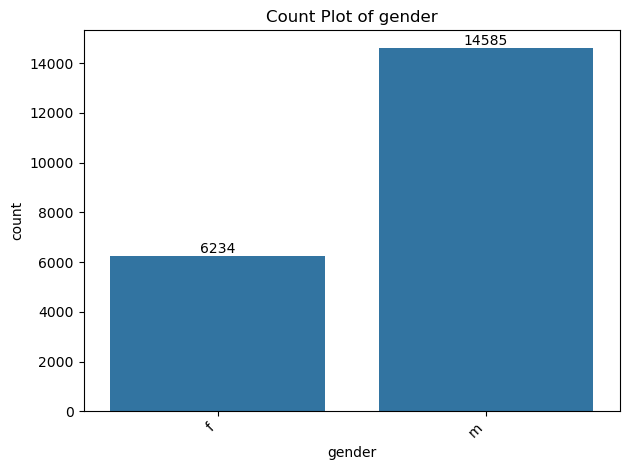

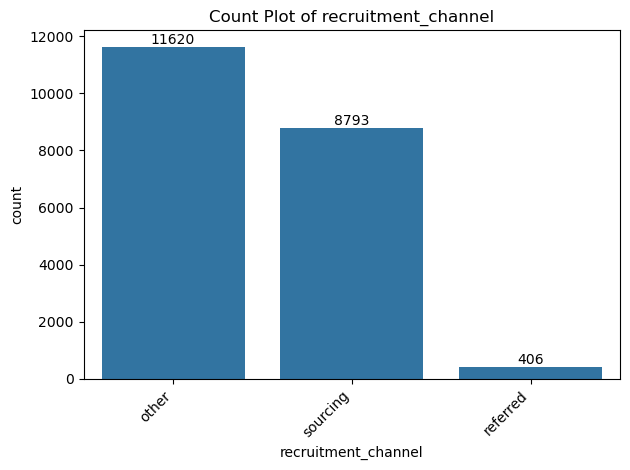

In [243]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    ax = sns.countplot(data = df, x = col)
    ax.bar_label(ax.containers[0])
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45,ha='right')
    plt.tight_layout()
    plt.show()
    

In [244]:
# Apply Scalers

In [245]:
#Select Numerical Columns 

In [246]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [247]:
def apply_scalers(data):
    scalers = {       # Create Scalers Dictionary
        "StandardScaler": StandardScaler(),
        "MinMaxScaler": MinMaxScaler(),
        "MaxAbsScaler": MaxAbsScaler(),
        "RobustScaler": RobustScaler()
    }
    scaled_data = {}
    for name, scaler in scalers.items():
        scaled = scaler.fit_transform(data[num_cols]) # Apply Scaling
        scaled_df = pd.DataFrame(scaled, columns=num_cols) # Convert Back to DataFrame
        scaled_data[name] = scaled_df # Store Result
        return scaled_data  # Returns all scaled datasets
scaled_results = apply_scalers(df)
scaled_results["StandardScaler"].head() # View StandardScaler result

    

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,1.562321,-0.422224,-0.606824,-0.276085,-0.304192,-0.753926,-0.154603,-0.935989
1,1.466276,-0.422224,-0.606824,-1.860596,-0.545283,-0.753926,-0.154603,-1.237107
2,-0.021570,2.938617,-0.606824,-1.068340,0.660172,-0.753926,-0.154603,0.117926
3,1.123205,-0.422224,-0.738998,0.516170,0.177990,-0.753926,-0.154603,-0.183193
4,0.317129,-0.422224,0.054047,-0.276085,-1.027466,-0.753926,-0.154603,0.343764


In [248]:
def apply_scalers(data):
    scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "RobustScaler": RobustScaler()
}
    scaled_data = {}
    for name, scaler in scalers.items():
        scaled = scaler.fit_transform(data[num_cols]) # Apply Scaling
        scaled_df = pd.DataFrame(scaled, columns=num_cols) # Convert Back to DataFrame
        scaled_data[name] = scaled_df # Store Result
    return scaled_data  # Returns all scaled datasets
scaled_results = apply_scalers(df)
scaled_results["MinMaxScaler"].head() # View MinMaxScaler result


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,0.950634,0.00,0.275,0.50,0.121212,0.0,0.0,0.200000
1,0.922853,0.00,0.275,0.00,0.090909,0.0,0.0,0.133333
2,0.492502,0.25,0.275,0.25,0.242424,0.0,0.0,0.433333
3,0.823622,0.00,0.250,0.75,0.181818,0.0,0.0,0.366667
4,0.590469,0.00,0.400,0.50,0.030303,0.0,0.0,0.483333


In [249]:
def apply_scalers(data):
    scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "RobustScaler": RobustScaler()
}
    scaled_data = {}
    for name, scaler in scalers.items():
        scaled = scaler.fit_transform(data[num_cols]) # Apply Scaling
        scaled_df = pd.DataFrame(scaled, columns=num_cols) # Convert Back to DataFrame
        scaled_data[name] = scaled_df # Store Result
    return scaled_data  # Returns all scaled datasets
scaled_results = apply_scalers(df)
scaled_results["MaxAbsScaler"].head() # View MaxAbsScaler result


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,0.950635,0.111111,0.516667,0.6,0.147059,0.0,0.0,0.515152
1,0.922856,0.111111,0.516667,0.2,0.117647,0.0,0.0,0.474747
2,0.492522,0.333333,0.516667,0.4,0.264706,0.0,0.0,0.656566
3,0.823629,0.111111,0.500000,0.8,0.205882,0.0,0.0,0.616162
4,0.590485,0.111111,0.600000,0.6,0.058824,0.0,0.0,0.686869


In [250]:
def apply_scalers(data):
    scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "RobustScaler": RobustScaler()
}
    scaled_data = {}
    for name, scaler in scalers.items():
        scaled = scaler.fit_transform(data[num_cols]) # Apply Scaling
        scaled_df = pd.DataFrame(scaled, columns=num_cols) # Convert Back to DataFrame
        scaled_data[name] = scaled_df # Store Result
    return scaled_data  # Returns all scaled datasets
scaled_results = apply_scalers(df)
scaled_results["RobustScaler"].head() # View RobustScaler result


,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,0.901191,0.0,-0.333333,0.0,0.0,0.0,0.0,-0.375000
1,0.845972,0.0,-0.333333,-2.0,-0.2,0.0,0.0,-0.541667
2,-0.009419,2.0,-0.333333,-1.0,0.8,0.0,0.0,0.208333
3,0.648734,0.0,-0.444444,1.0,0.4,0.0,0.0,0.041667
4,0.185306,0.0,0.222222,0.0,-0.6,0.0,0.0,0.333333


#### RobustScaler is best because it handles outliers and gives stable scaling.

In [251]:
# Create Baseline ML Model for Binary Classification Problem
# We will be using 3 models for this problem -  XGBoost, CatBoost, LightGBM
# Run the dataset through XGBoost to predict the target variable and check the accuracy
# Run the dataset through CatBoost to predict the target variable and check the accuracy
# Run the dataset through LightGBM to predict the target variable and check the accuracy


In [252]:
# Define Input (X)Independent variables and Target (y) Dependent variable

In [253]:
df = df.drop('employee_id', axis=1) # Emp id is not useful

In [254]:
X = df.drop('KPIs_met >80%', axis=1)
y = df['KPIs_met >80%']  # ‘KPIs_met >80%’ as target because it represents performance (0/1).

In [255]:
X = pd.get_dummies(X, drop_first=True) # Converts categorical (text) data → numerical data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
) # Split  Data

In [256]:
# Train Models ' XGBoost: eXtreme Gradient Boosting '

In [257]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:51:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7214217098943324


In [258]:
# Train Models ' CatBoost: Categorical Boosting '

cat = CatBoostClassifier(verbose=0)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))

CatBoost Accuracy: 0.7276657060518732


In [259]:
# Train Models ' LightGBM: Light Gradient Boosting Machine '

lgb = LGBMClassifier()

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6032, number of negative: 10623
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 242
[LightGBM] [Info] Number of data points in the train set: 16655, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.362174 -> initscore=-0.565943
[LightGBM] [Info] Start training from score -0.565943
LightGBM Accuracy: 0.722862632084534


In [260]:
# Compare Results

print("\nFinal Comparison:")
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("CatBoost:", accuracy_score(y_test, y_pred_cat))
print("LightGBM:", accuracy_score(y_test, y_pred_lgb))


Final Comparison:
XGBoost: 0.7214217098943324
CatBoost: 0.7276657060518732
LightGBM: 0.722862632084534


#### CatBoost has the highest accuracy (0.7277), So CatBoost is the best model for Dataset

#### Now,Create Evaluation Function

In [261]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [262]:
def evaluate_model(y_test, y_pred):  # This function will check model performance
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return acc, cm

In [264]:
# Run Models on Each Scaler, Separate X and y BEFORE scaling,bcz Never scale the target variable (y),Only scale input features (X)

X = df.drop('KPIs_met >80%', axis=1)
y = df['KPIs_met >80%']

In [265]:
X = pd.get_dummies(X, drop_first=True) # Convert Categorical Data in to Number 0/1
X_train, X_test, y_train, y_test = train_test_split(X, y) 
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [266]:
results = []

for scaler_name, scaler in {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "RobustScaler": RobustScaler()
}.items():
    
    print(f"\n Using {scaler_name}")
    
    # Scale only X
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )
    
    models = {
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "CatBoost": CatBoostClassifier(verbose=0),
        "LightGBM": LGBMClassifier()
    }
    
    for model_name, model in models.items():
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        print(f"{model_name} Accuracy: {acc}")
        print("Confusion Matrix:\n", cm)
        
        results.append([scaler_name, model_name, acc])


 Using StandardScaler


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:59:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7214217098943324
Confusion Matrix:
 [[2255  396]
 [ 764  749]]
CatBoost Accuracy: 0.7276657060518732
Confusion Matrix:
 [[2308  343]
 [ 791  722]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6032, number of negative: 10623
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 16655, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.362174 -> initscore=-0.565943
[LightGBM] [Info] Start training from score -0.565943
LightGBM Accuracy: 0.722862632084534
Confusion Matrix:
 [[2291  360]
 [ 794  719]]

 Using MinMaxScaler


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:59:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7214217098943324
Confusion Matrix:
 [[2255  396]
 [ 764  749]]
CatBoost Accuracy: 0.7276657060518732
Confusion Matrix:
 [[2308  343]
 [ 791  722]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6032, number of negative: 10623
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 238
[LightGBM] [Info] Number of data points in the train set: 16655, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.362174 -> initscore=-0.565943
[LightGBM] [Info] Start training from score -0.565943
LightGBM Accuracy: 0.722862632084534
Confusion Matrix:
 [[2291  360]
 [ 794  719]]

 Using MaxAbsScaler


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:59:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7214217098943324
Confusion Matrix:
 [[2255  396]
 [ 764  749]]
CatBoost Accuracy: 0.7276657060518732
Confusion Matrix:
 [[2308  343]
 [ 791  722]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6032, number of negative: 10623
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 242
[LightGBM] [Info] Number of data points in the train set: 16655, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.362174 -> initscore=-0.565943
[LightGBM] [Info] Start training from score -0.565943
LightGBM Accuracy: 0.722862632084534
Confusion Matrix:
 [[2291  360]
 [ 794  719]]

 Using RobustScaler


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:00:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7214217098943324
Confusion Matrix:
 [[2255  396]
 [ 764  749]]
CatBoost Accuracy: 0.7276657060518732
Confusion Matrix:
 [[2308  343]
 [ 791  722]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6032, number of negative: 10623
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002932 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 237
[LightGBM] [Info] Number of data points in the train set: 16655, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.362174 -> initscore=-0.565943
[LightGBM] [Info] Start training from score -0.565943
LightGBM Accuracy: 0.722862632084534
Confusion Matrix:
 [[2291  360]
 [ 794  719]]


In [281]:
# Create Final Comparison Table
results_df = pd.DataFrame(results, columns=["Scaler", "Model", "Accuracy"])
results_df

,Scaler,Model,Accuracy
0,StandardScaler,XGBoost,0.721422
1,StandardScaler,CatBoost,0.727666
2,StandardScaler,LightGBM,0.722863
3,MinMaxScaler,XGBoost,0.721422
4,MinMaxScaler,CatBoost,0.727666
5,MinMaxScaler,LightGBM,0.722863
6,MaxAbsScaler,XGBoost,0.721422
7,MaxAbsScaler,CatBoost,0.727666
8,MaxAbsScaler,LightGBM,0.722863
9,RobustScaler,XGBoost,0.721422


In [290]:
# Find Best Combination
best = results_df.sort_values(by="Accuracy", ascending=False).iloc[0] # iloc[0] = gives best row
best_df = best.to_frame().T
best_df

,Scaler,Model,Accuracy
1,StandardScaler,CatBoost,0.727666


In [291]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

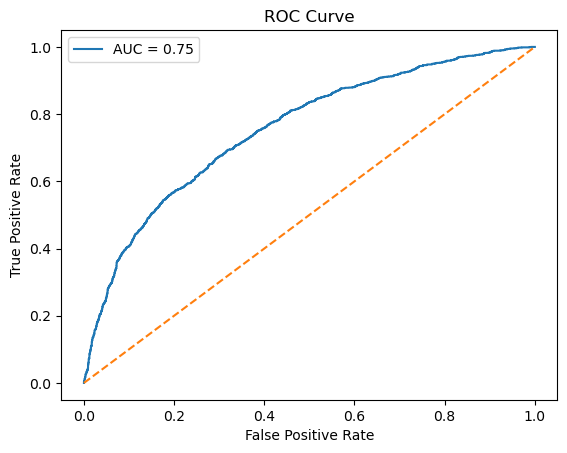

In [292]:
y_prob = model.predict_proba(X_test)[:, 1]  # [:,1] : Take probability of class 1 (positive class),required for ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) # Calculate ROC Values: fpr = x - axis,tpr = Y - axis, thresholds - different cutoff values
roc_auc = auc(fpr, tpr) # Calculate AUC (Area Under Curve) Score
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve") # ROC: Receiver Operating Characteristic: How well model distinguishes between classes (0 vs 1)
plt.legend()

plt.show()